# 1 — Breast Cancer Wisconsin: XGBoost end-to-end baseline

**The goal of this notebook** is to walk the *whole* pipeline once on an easy dataset, so the moving parts are clear before we add complexity in later stages.

### A 60-second mental model of gradient boosting
XGBoost builds an **additive ensemble of shallow decision trees**. Each new tree is fit to the *gradient* (and, in XGBoost, the *hessian* — second-order/Newton optimization) of the loss of the ensemble so far. Contrast:
- **Random Forest** = *bagging*: many deep trees grown independently in parallel, then averaged.
- **Boosting** = *sequential*: each tree corrects the errors the current ensemble still makes.

XGBoost adds a regularized objective (L1/L2 on leaf weights + a complexity penalty), histogram-based split finding (`tree_method="hist"`), and sparsity-aware handling of missing values.

### Two APIs, one engine
We'll train the same model two ways and confirm they agree:
- the **scikit-learn API** (`XGBClassifier`), and
- the **native API** (`xgb.train` + `QuantileDMatrix`).

Everything below reuses the installable `xgblearn` package so the lessons compound across stages.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

from xgblearn.config import ModelConfig, set_global_seed
from xgblearn.data.loaders import load_dataset
from xgblearn.data.splits import train_val_test_split
from xgblearn.models.train import predict_proba_binary, train_native, train_sklearn
from xgblearn.models.evaluate import binary_classification_metrics

set_global_seed(42)


def pick_device() -> str:
    """Use the GPU if a 1-round CUDA train succeeds, else fall back to CPU.
    Makes this notebook portable across machines."""
    if not xgb.build_info().get("USE_CUDA", False):
        return "cpu"
    try:
        x = np.random.default_rng(0).random((32, 3), dtype=np.float32)
        d = xgb.QuantileDMatrix(x, label=(x[:, 0] > 0.5).astype(np.int32))
        xgb.train({"device": "cuda", "tree_method": "hist"}, d, num_boost_round=1)
        return "cuda"
    except Exception:
        return "cpu"


DEVICE = pick_device()
print(f"xgboost {xgb.__version__}  |  training on: {DEVICE}")

xgboost 3.3.0  |  training on: cuda


In [2]:
ds = load_dataset("breast_cancer")
print(f"{ds.name}: {ds.n_samples} rows x {ds.n_features} features ({ds.task})")
print("positive rate:", round(float(ds.y.mean()), 3))
ds.X.head()

breast_cancer: 569 rows x 30 features (binary)
positive rate: 0.627


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## The splitting discipline

We make **three** partitions:
- **train** — fits the trees.
- **validation** — drives early stopping (and, later, tuning).
- **test** — *the test set is sacred*: it is touched exactly once, at the very end, to get an honest estimate of generalization.

`val_size` is a fraction of the non-test data, so with `test_size=0.2, val_size=0.2` we get roughly **64% / 16% / 20%**. We stratify so each split keeps the same class balance.

In [3]:
splits = train_val_test_split(
    ds.X, ds.y, test_size=0.2, val_size=0.2, stratify=True, seed=42
)
print("sizes      :", splits.sizes)
print("pos rates  :", {
    "train": round(float(splits.y_train.mean()), 3),
    "val": round(float(splits.y_val.mean()), 3),
    "test": round(float(splits.y_test.mean()), 3),
})

sizes      : {'train': 364, 'val': 91, 'test': 114}
pos rates  : {'train': 0.626, 'val': 0.626, 'test': 0.632}


## The scikit-learn API

`XGBClassifier` feels like any sklearn estimator. Two XGBoost-specific notes:
- `early_stopping_rounds` goes in the **constructor** (since 1.6+), and `eval_set` goes to `.fit()`. Predictions then automatically use `best_iteration`.
- `n_estimators` is the same knob as the native API's `num_boost_round`.

Our `ModelConfig` centralizes these settings. We override `device` with the auto-detected value so this runs anywhere.

In [4]:
cfg = ModelConfig(
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    device=DEVICE,
    tree_method="hist",
    num_boost_round=500,
    early_stopping_rounds=50,
    seed=42,
    params={"learning_rate": 0.1, "max_depth": 4, "subsample": 0.9},
)

sk = train_sklearn(splits, cfg)
sk_proba = predict_proba_binary(sk, splits.X_val)
print("best_iteration:", sk.best_iteration)
binary_classification_metrics(splits.y_val.to_numpy(), sk_proba)

best_iteration: 69


C:\Users\s2608\Documents\sumeet\ml-finetuning\xgboost-lab\.venv\Lib\site-packages\xgboost\core.py:553: UserWarning: [11:41:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


{'logloss': 0.13940787315368652,
 'roc_auc': 0.9907120743034056,
 'pr_auc': 0.9943716255963257,
 'accuracy': 0.9560439560439561,
 'brier': 0.03711086884140968}

## The native API + `QuantileDMatrix`

The native API is `xgb.train(params, dtrain, num_boost_round, evals=...)` returning a `Booster`. We feed it a **`QuantileDMatrix`**, which pre-bins the features (lower memory, ideal on GPU). The validation matrix passes `ref=dtrain` so both share the same bin edges. Early stopping is an `xgb.callback.EarlyStopping` callback with `save_best=True`.

Same hyperparameters + same seed → the two APIs should produce **the same model**.

In [5]:
nat = train_native(splits, cfg)
nat_proba = predict_proba_binary(nat, splits.X_val)
print("best_iteration:", nat.best_iteration)
print("max |sklearn - native| on val proba:", float(np.max(np.abs(sk_proba - nat_proba))))
binary_classification_metrics(splits.y_val.to_numpy(), nat_proba)

best_iteration: 69
max |sklearn - native| on val proba: 0.0


{'logloss': 0.13940787315368652,
 'roc_auc': 0.9907120743034056,
 'pr_auc': 0.9943716255963257,
 'accuracy': 0.9560439560439561,
 'brier': 0.03711086884140968}

## Learning curves — diagnosing over/underfitting

`evals_result()` records the metric per boosting round on each eval set. Plotting train vs. validation tells us whether we're under- or over-fitting, and where early stopping kicked in. A widening gap (train keeps improving, val flattens/worsens) is the signature of overfitting.

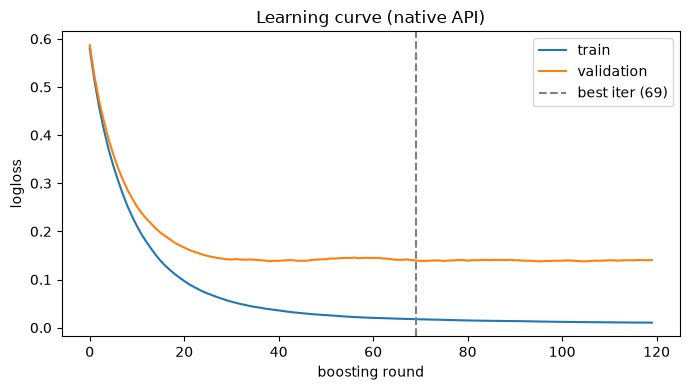

In [6]:
hist = nat.evals_result
rounds = range(len(hist["train"]["logloss"]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds, hist["train"]["logloss"], label="train")
ax.plot(rounds, hist["val"]["logloss"], label="validation")
if nat.best_iteration is not None:
    ax.axvline(nat.best_iteration, ls="--", c="grey", label=f"best iter ({nat.best_iteration})")
ax.set_xlabel("boosting round")
ax.set_ylabel("logloss")
ax.set_title("Learning curve (native API)")
ax.legend()
plt.tight_layout()
plt.show()

## The held-out test set (touched once)

Only now — after model selection is done — do we look at the test set, for an honest generalization estimate.

In [7]:
test_proba = predict_proba_binary(nat, splits.X_test)
binary_classification_metrics(splits.y_test.to_numpy(), test_proba)

{'logloss': 0.12311986088752747,
 'roc_auc': 0.9917328042328042,
 'pr_auc': 0.9950670990657982,
 'accuracy': 0.9385964912280702,
 'brier': 0.03957148641347885}

## What to notice (gotchas)

- **The two APIs are one engine.** With identical params + seed, sklearn and native predictions match to floating-point noise. Pick the API that fits your workflow (sklearn for Pipelines/SearchCV; native for `QuantileDMatrix` memory control and advanced features).
- **`device="cuda"`, not `gpu_hist`.** The old `tree_method="gpu_hist"` / `gpu_id` were removed in 3.1.0. The modern knob is `device="cuda"` + `tree_method="hist"`.
- **The benign device-mismatch warning.** Predicting with CPU data against a GPU-resident booster prints *"Falling back to prediction using DMatrix due to mismatched devices"*. It's a data-placement note, **not** a Blackwell problem — avoid it by keeping data and booster on the same device.
- **No feature scaling.** We did zero standardization. Tree splits are threshold-based and invariant to monotonic transforms — scaling buys nothing here (a linear-model habit).
- **The test set was touched once.** Everything before the last cell used only train/validation.
- **Reproducibility.** `make train` logs each run to MLflow with params, metrics, a model signature, and tags for git commit + seed + data fingerprint. Open it with `make mlflow-ui`.